# Schlichting self-similar jet
See https://en.wikipedia.org/wiki/Schlichting_jet

In [1]:
# Add any possible locations of amr-wind-frontend here
import sys, os
curdir = os.getcwd()
extradirs = ['../', './',
             os.path.dirname(curdir),
            ]
for x in extradirs: sys.path.insert(1, x)

import numpy as np
import matplotlib.pyplot as plt
import SANDwake3D_laminar as SANDwake3D

In [2]:
import numpy as np
import matplotlib.pyplot as plt

$$
Re = \frac{1}{\nu} \left( \frac{J}{2\pi \rho} \right)^{1/2}
$$

$$
\eta = \frac{r}{x} = \frac{\sqrt{y^2 + z^2}}{x}
$$

$$
u = \frac{\nu}{x} \frac{F'(\eta)}{\eta}
$$

$$
v = \frac{\nu}{x} \left[ F'(\eta) - \frac{F}{\eta} \right]
$$

$$
F(\eta) = \frac{4 (\textrm{Re} ~\eta)^2}{32/3 - (\textrm{Re} ~\eta)^2} 
$$

$$
F'(\eta) = \frac{8 Re^2 \eta}{32/3 + Re^2 \eta^2} - \frac{8 Re^4 \eta^3}{(32/3 + Re^2 \eta^2)^2}
$$

In [3]:
def Ffunc(eta,Re):
    Re_eta = Re*eta
    return (4.0*Re_eta**2)/(32.0/3.0 + Re_eta**2)

def Fprime(eta, Re):
    Re_eta = Re*eta
    denom  = 32.0/3.0 + Re_eta**2
    return (8.0*eta*Re**2)/denom - (8.0*(Re**4)*(eta**3))/denom**2

def getU(x, y, z, nu, Re):
    eta = np.sqrt(y**2 + z**2)/x
    #F = Ffunc(eta, Re)
    Fp= Fprime(eta, Re)
    u = nu/x*(Fp/eta)
    return u

def getV(x, y, z, nu, Re):
    eta = np.sqrt(y**2 + z**2)/x
    F = Ffunc(eta, Re)
    Fp= Fprime(eta, Re)
    v = nu/x*(Fp - F/eta)
    return v

In [4]:
nu = 0.1
Re = 50.0
x0  = 20.0

Ny = 150
Nz = 150
ymax, zmax = 10, 10
yvec = np.linspace(-ymax,ymax,Ny)
zvec = np.linspace(-zmax,zmax,Nz)

In [5]:
# Set up initial conditions
ym, zm = np.meshgrid(yvec, zvec, indexing='ij')

rm = np.sqrt(ym**2 + zm**2)
ny = ym/rm
nz = zm/rm

Ux = getU(x0, ym, zm, nu, Re)
Ur = getV(x0, ym, zm, nu, Re)

# Map to (y,z) coordinates
V  = Ur*ny
W  = Ur*nz

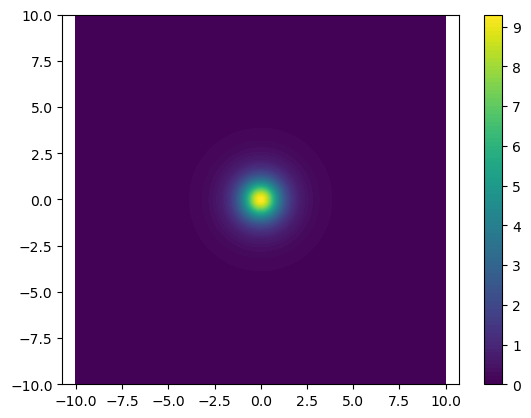

In [6]:
plt.contourf(ym, zm, getU(x0, ym, zm, nu, Re), levels=101, )
plt.axis('equal')
plt.colorbar()

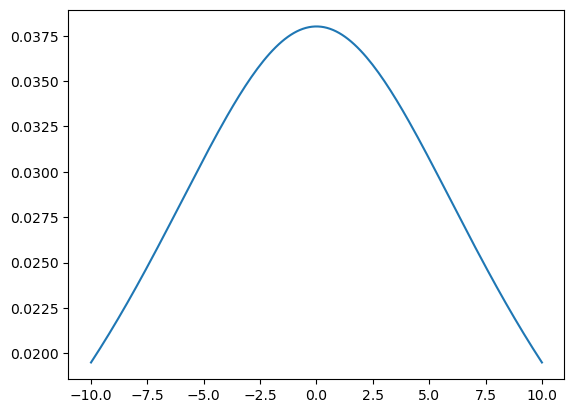

In [7]:
#plt.plot(yvec, Ux[:,Nz//2])
#plt.plot(yvec, V[:,Nz//2])
plt.plot(zvec, V[0,:])

## Set up RANS

In [8]:
# Set boundary conditions
ubc = {}
ubc['ylo'] = {'type':'dirichlet', 'value':0.0}
ubc['yhi'] = {'type':'dirichlet', 'value':0.0}
ubc['zlo'] = {'type':'dirichlet', 'value':0.0}
ubc['zhi'] = {'type':'dirichlet', 'value':0.0}

vbc = {}
vbc['ylo'] = {'type':'dirichlet', 'value':0.07}
vbc['yhi'] = {'type':'dirichlet', 'value':0.0}
vbc['zlo'] = {'type':'dirichlet', 'value':0.0}
vbc['zhi'] = {'type':'dirichlet', 'value':0.0}

wbc = {}
wbc['ylo'] = {'type':'dirichlet', 'value':0.0}
wbc['yhi'] = {'type':'dirichlet', 'value':0.0}
wbc['zlo'] = {'type':'dirichlet', 'value':0.0}
wbc['zhi'] = {'type':'dirichlet', 'value':0.0}

allbc = {'u':ubc, 'v':vbc, 'w':wbc}

In [9]:
dy   = np.mean(np.diff(yvec))
dz   = np.mean(np.diff(zvec))
print(dy)
print(dz)

0.1342281879194631
0.1342281879194631


In [10]:
# Set parameters
params = {}
params['nu']=nu

In [11]:
phiinit = {}
phiinit['u'] = Ux
phiinit['v'] = V
phiinit['w'] = W

In [16]:
dx  = 1
#xvec = np.arange(xvecplot[0], xvecplot[-1]+1.0E-6, dx)
xvec = [x0, x0+dx, x0+2*dx, x0+3*dx]
phi = SANDwake3D.marchSystem(phiinit, xvec, dy, dz, params, allbc, SANDwake3D.laminar_eqns, 
                             verbose=True, maxiter=200, tol=1.0E-4)

x = 21.0 dx = 1.0
0 {'u': 3.419981107024371, 'w': 3.523965155017184, 'v': 22.786834289176717}
1 {'u': 7.170921071178568, 'w': 0.9970518599587371, 'v': 23.22899799685841}
2 {'u': 7.291270557380614, 'w': 0.4919492899392902, 'v': 29.683177704200766}
3 {'u': 3.4227226517726987, 'w': 1.258587452612765, 'v': 31.385147805606017}
4 {'u': 3.6305581141085894, 'w': 0.5266712701822315, 'v': 11.725561930814052}
5 {'u': 2.5904000189609637, 'w': 0.7853247879625509, 'v': 14.830609911131862}
6 {'u': 2.7763227551850864, 'w': 0.5083961248320593, 'v': 6.838750651635856}
7 {'u': 1.9143726200905786, 'w': 0.49318650766413535, 'v': 9.988299727747052}
8 {'u': 1.5963757465318724, 'w': 0.35597949193128353, 'v': 4.038536153826091}
9 {'u': 1.214778356344393, 'w': 0.1648462836159463, 'v': 4.349995228835423}
10 {'u': 0.8870492675610797, 'w': 0.23875923588110975, 'v': 2.8927167102854496}
11 {'u': 0.8302895665675892, 'w': 0.0503848204467393, 'v': 2.1717638774071237}
12 {'u': 0.5647207554539492, 'w': 0.1202749796153022

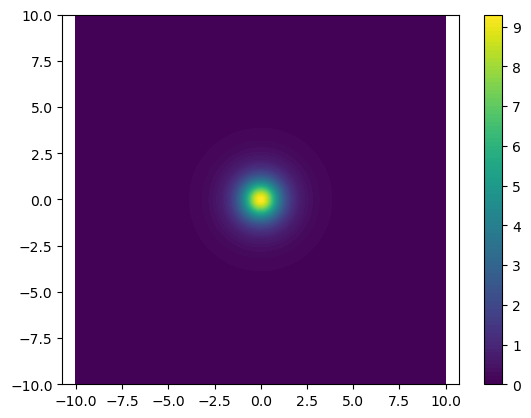

In [21]:
plt.contourf(ym, zm, phi['u'][0,:,:], levels=101, )
plt.axis('equal')
plt.colorbar()